# *ASSIGNMENT-3: Sending messages through a network*

In [134]:
import networkx as nx
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import random
from itertools import combinations
from collections import Counter

In [135]:
MESSAGE_TRUE = "Real"
MESSAGE_MUTATED = "Altered"
MESSAGE_FAKE = "Fake"
MESSAGE_NONE = None
random.seed(42)

In [136]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
df = pd.read_csv(DATASET_PATH)

In [137]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [138]:
G = build_graph(df)

## Verifiers and Unintentional nodes

In [139]:
def assign_roles(G, n_verifiers=5, n_unintentional=5, selection_strategy="random", betweenness=None):
    nodes = list(G.nodes())
    roles = {node: "normal" for node in nodes} # Tutti i nodi partono come normali
    # Verifiers casuali: gli unici che possono iniziare la diffusione della notizia corretta.
    verifiers = random.sample(nodes, n_verifiers)
    for v in verifiers:
        roles[v] = "verifier"
    remaining = [n for n in nodes if n not in verifiers] # tolgo i verifiers per la scelta degli unintentional
    if selection_strategy == "random":
        unint = random.sample(remaining, n_unintentional) # scelti a caso
    elif selection_strategy == "degree":
        ranked = sorted(remaining, key=lambda n: G.degree[n], reverse=True)
        unint = ranked[:n_unintentional] # scelti con grado più alto
    elif selection_strategy == "betweenness":
        if betweenness is None:
            raise ValueError("Passare la betweenness già calcolata.")
        ranked = sorted(remaining, key=lambda n: betweenness[n], reverse=True)
        unint = ranked[:n_unintentional] # scelti con betweenness più alta
    else:
        raise ValueError("Strategia non valida.")
    for u in unint:
        roles[u] = "unintentional" # i nodi scelti diventano unintentional
    return roles

In [140]:
def adopt_message(node, lista_vicini_per_nodo, messages, threshold):
    vicini = lista_vicini_per_nodo[node]
    if not vicini: # Se il nodo non ha vicini → non può adottare nulla.
        return MESSAGE_NONE

    # Conto quanti vicini hanno adottato ciascun messaggio
    counts = {}
    for vicino in vicini:
        msg = messages[vicino]
        if msg is not None:
            counts[msg] = counts.get(msg, 0) + 1
    if not counts:
        return MESSAGE_NONE
    majority_msg = max(counts, key=counts.get) # messaggio più diffuso tra i vicini
    frac = counts[majority_msg] / len(vicini) # frazione di vicini che hanno il messaggio
    if frac >= threshold: # controllo la soglia
        return majority_msg
    return MESSAGE_NONE

In [141]:
def ricerca_lista_vicini_per_nodo(G):
    return {node: list(G.neighbors(node)) for node in G.nodes()}

In [142]:
def simulate_spread(G, roles, threshold=0.3, max_steps=20, lista_vicini_per_nodo=None):
    if lista_vicini_per_nodo is None:
        lista_vicini_per_nodo = ricerca_lista_vicini_per_nodo(G)
    # all’inizio nessun nodo ha adottato un messaggio
    messages = {
        node: MESSAGE_NONE
        for node in G.nodes()
    }
    # I verifiers iniziano con il messaggio corretto
    for node, role in roles.items():
        if role == "verifier":
            messages[node] = MESSAGE_TRUE
    # max_steps per evitare loop infiniti
    for step in range(max_steps):
        new_messages = messages.copy()
        changed = False
        for node in G.nodes():
            role = roles[node]
            if role == "verifier": # I verifiers non cambiano mai il loro messaggio
                continue
            if role == "unintentional": # Gli unintentional adottano il messaggio solo una volta
                if messages[node] is None:
                    adopted = adopt_message(node, lista_vicini_per_nodo, messages, threshold)
                    if adopted == MESSAGE_TRUE: # Se ricevono MESSAGE_TRUE dai vicini
                        new_messages[node] = MESSAGE_MUTATED # lo mutano
                        changed = True
                continue
            if role == "normal":
                adopted = adopt_message(node, lista_vicini_per_nodo, messages, threshold)
                if adopted != messages[node]: # Se il messaggio adottato è diverso da quello attuale
                    new_messages[node] = adopted
                    changed = True
        messages = new_messages # Aggiorno i messaggi dopo aver controllato tutti i nodi
        if not changed:
            break
    return messages

In [143]:
def analyze(messages):
    total = len(messages)
    counter = Counter(messages.values()) # Conta quante volte ogni messaggio è stato adottato
    return {
        "true": counter[MESSAGE_TRUE] / total,
        "mutated": counter[MESSAGE_MUTATED] / total,
        "fake": counter[MESSAGE_FAKE] / total,
        "none": counter[None] / total
    }

In [144]:
# Grafo piccolo
G_small = nx.erdos_renyi_graph(10, 0.3, seed=42)
num_verifiers = 2
threshold = 0.3

max_unintentional = len(G_small.nodes()) - num_verifiers
unintentional_values = range(0, max_unintentional + 1)
mutated_fractions = []

for num_unintentional in unintentional_values:
    random.seed(0) # Per garantire la riproducibilità dei risultati
    roles = assign_roles(G_small, n_verifiers=num_verifiers, n_unintentional=num_unintentional)
    messages = simulate_spread(G_small, roles, threshold=threshold)
    analysis = analyze(messages)
    mutated_fractions.append(analysis["mutated"])

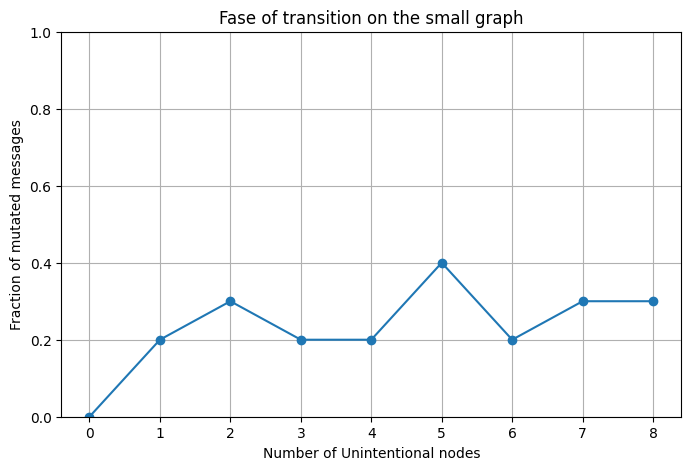

In [145]:
plt.figure(figsize=(8, 5))
plt.plot(unintentional_values, mutated_fractions, marker='o')
plt.xlabel("Number of Unintentional nodes")
plt.ylabel("Fraction of mutated messages")
plt.title("Fase of transition on the small graph")
plt.grid(True)
plt.xticks(unintentional_values)
plt.ylim(0, 1)
plt.show()

In [146]:
print("SMALL GRAPH")
for u, m in zip(unintentional_values, mutated_fractions):
    print(f"Unintentional={u} → mutated={m:.4f}")

SMALL GRAPH
Unintentional=0 → mutated=0.0000
Unintentional=1 → mutated=0.2000
Unintentional=2 → mutated=0.3000
Unintentional=3 → mutated=0.2000
Unintentional=4 → mutated=0.2000
Unintentional=5 → mutated=0.4000
Unintentional=6 → mutated=0.2000
Unintentional=7 → mutated=0.3000
Unintentional=8 → mutated=0.3000


### Anime Graph

In [147]:
unintentional_values = [0, 5, 10, 20, 50, 100, 150, 200]
mutated_random = []

for u in unintentional_values:
    random.seed(0) # Per garantire la riproducibilità dei risultati
    roles = assign_roles(G, n_verifiers=50, n_unintentional=u, selection_strategy="random")
    messages = simulate_spread(G, roles, threshold=0.05)
    analysis = analyze(messages)
    mutated_random.append(analysis["mutated"])

In [148]:
mutated_degree = []
for u in unintentional_values:
    random.seed(0) # Per garantire la riproducibilità dei risultati
    roles = assign_roles(G, n_verifiers=50, n_unintentional=u, selection_strategy="degree")
    messages = simulate_spread(G, roles, threshold=0.05)
    analysis = analyze(messages)
    mutated_degree.append(analysis["mutated"])

In [149]:
thresholds = [0.01, 0.05, 0.1, 0.2, 0.3]
mutated_threshold = []

for t in thresholds:
    random.seed(0) # Per garantire la riproducibilità dei risultati
    roles = assign_roles(G, n_verifiers=50, n_unintentional=50, selection_strategy="random")
    messages = simulate_spread(G, roles, threshold=t)
    analysis = analyze(messages)
    mutated_threshold.append(analysis["mutated"])

In [150]:
verifier_values = [10, 20, 50, 100, 200]
mutated_verifiers = []

for v in verifier_values:
    random.seed(0) # Per garantire la riproducibilità dei risultati
    roles = assign_roles(G, n_verifiers=v, n_unintentional=50, selection_strategy="random")
    messages = simulate_spread(G, roles, threshold=0.05)
    analysis = analyze(messages)
    mutated_verifiers.append(analysis["mutated"])

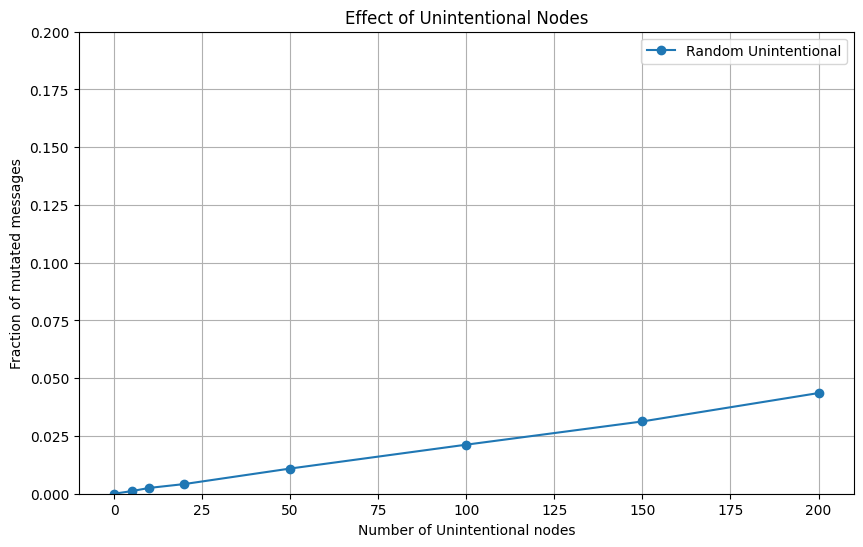

In [151]:
plt.figure(figsize=(10, 6))
plt.plot(unintentional_values, mutated_random, marker='o', label='Random Unintentional')
plt.xlabel("Number of Unintentional nodes")
plt.ylabel("Fraction of mutated messages")
plt.title("Effect of Unintentional Nodes")
plt.grid(True)
plt.legend()
plt.ylim(0, 0.2)
plt.show()

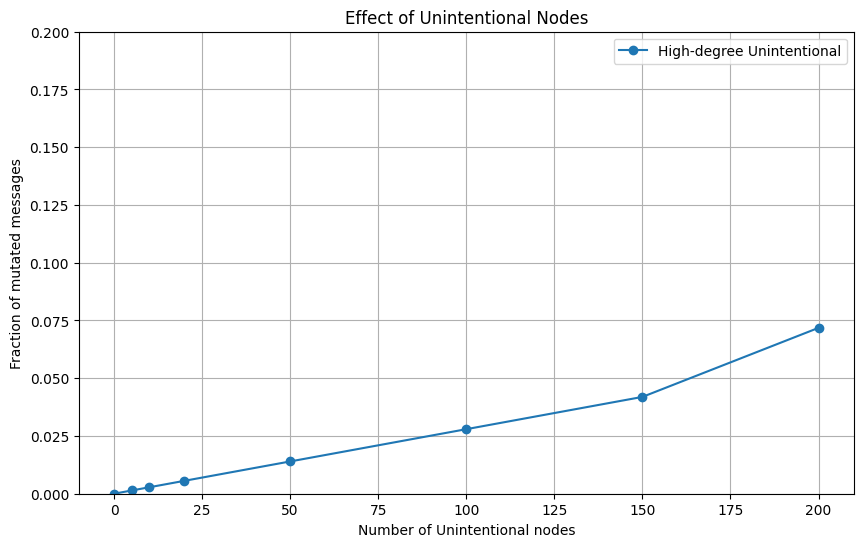

In [152]:
plt.figure(figsize=(10, 6))
plt.plot(unintentional_values, mutated_degree, marker='o', label='High-degree Unintentional')
plt.xlabel("Number of Unintentional nodes")
plt.ylabel("Fraction of mutated messages")
plt.title("Effect of Unintentional Nodes")
plt.grid(True)
plt.legend()
plt.ylim(0, 0.2)
plt.show()

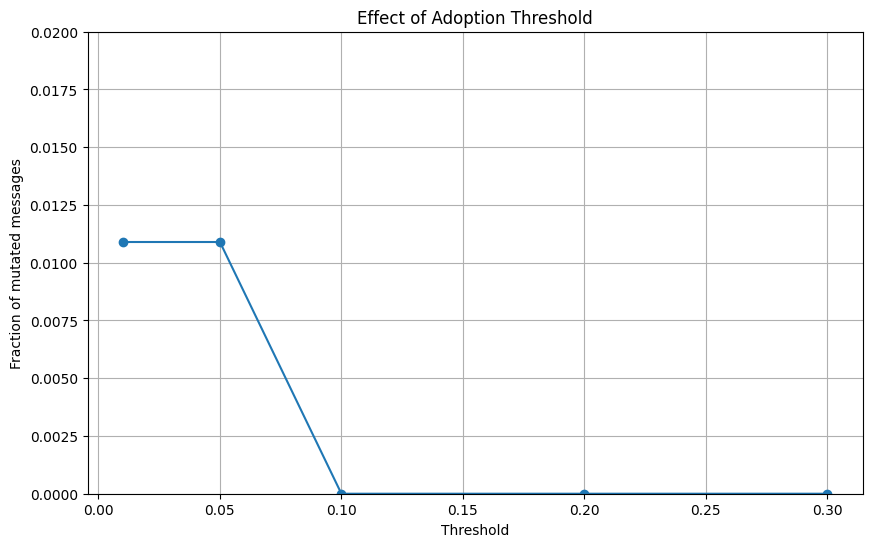

In [153]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, mutated_threshold, marker='o')
plt.xlabel("Threshold")
plt.ylabel("Fraction of mutated messages")
plt.title("Effect of Adoption Threshold")
plt.grid(True)
plt.ylim(0, 0.02)
plt.show()

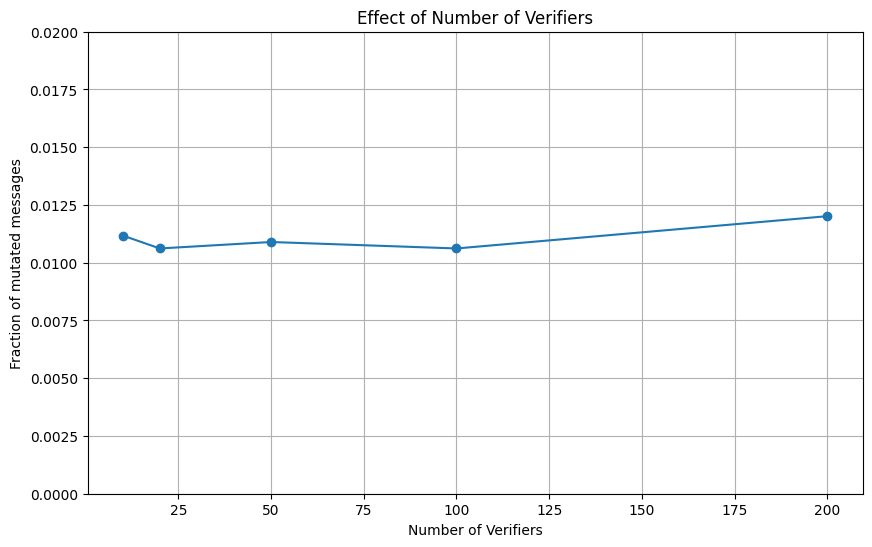

In [154]:
plt.figure(figsize=(10, 6))
plt.plot(verifier_values, mutated_verifiers, marker='o')
plt.xlabel("Number of Verifiers")
plt.ylabel("Fraction of mutated messages")
plt.title("Effect of Number of Verifiers")
plt.grid(True)
plt.ylim(0, 0.02)
plt.show()

In [155]:
print("=== RANDOM UNINTENTIONAL ===")
for u, m in zip(unintentional_values, mutated_random):
    print(f"Unintentional={u} → mutated={m:.4f}")

print("\n=== HIGH-DEGREE UNINTENTIONAL ===")
for u, m in zip(unintentional_values, mutated_degree):
    print(f"Unintentional={u} → mutated={m:.4f}")

print("\n=== THRESHOLD SWEEP ===")
for t, m in zip(thresholds, mutated_threshold):
    print(f"Threshold={t} → mutated={m:.4f}")

print("\n=== VERIFIERS SWEEP ===")
for v, m in zip(verifier_values, mutated_verifiers):
    print(f"Verifiers={v} → mutated={m:.4f}")


=== RANDOM UNINTENTIONAL ===
Unintentional=0 → mutated=0.0000
Unintentional=5 → mutated=0.0011
Unintentional=10 → mutated=0.0025
Unintentional=20 → mutated=0.0042
Unintentional=50 → mutated=0.0109
Unintentional=100 → mutated=0.0212
Unintentional=150 → mutated=0.0313
Unintentional=200 → mutated=0.0436

=== HIGH-DEGREE UNINTENTIONAL ===
Unintentional=0 → mutated=0.0000
Unintentional=5 → mutated=0.0014
Unintentional=10 → mutated=0.0028
Unintentional=20 → mutated=0.0056
Unintentional=50 → mutated=0.0140
Unintentional=100 → mutated=0.0279
Unintentional=150 → mutated=0.0419
Unintentional=200 → mutated=0.0718

=== THRESHOLD SWEEP ===
Threshold=0.01 → mutated=0.0109
Threshold=0.05 → mutated=0.0109
Threshold=0.1 → mutated=0.0000
Threshold=0.2 → mutated=0.0000
Threshold=0.3 → mutated=0.0000

=== VERIFIERS SWEEP ===
Verifiers=10 → mutated=0.0112
Verifiers=20 → mutated=0.0106
Verifiers=50 → mutated=0.0109
Verifiers=100 → mutated=0.0106
Verifiers=200 → mutated=0.0120


### For a given threshold value, what is the minimum number of Unintentional nodes required for more than half of the network to receive corrupted information?

In [156]:
def find_critical_unintentional_number(G, threshold, neighbors):
    low, high = 0, len(G.nodes()) - 50
    numero_critico_unintentional = None

    while low <= high:
        mid = (low + high) // 2
        roles = assign_roles(G, n_verifiers=50, n_unintentional=mid, selection_strategy="degree")
        messages = simulate_spread(G, roles, threshold, max_steps=8, lista_vicini_per_nodo=neighbors)
        mutated = analyze(messages)["mutated"]
        if mutated > 0.5:
            numero_critico_unintentional = mid
            high = mid - 1
        else:
            low = mid + 1
    return numero_critico_unintentional

In [157]:
punti_critici = {}
# Giant component
largest_cc = max(nx.connected_components(G), key=len)
G_gc = G.subgraph(largest_cc).copy()
# Precompute neighbors
neighbors = ricerca_lista_vicini_per_nodo(G_gc)
for threshold in thresholds:
    punti_critici[threshold] = find_critical_unintentional_number(G_gc, threshold, neighbors)
print(punti_critici)

{0.01: 404, 0.05: None, 0.1: None, 0.2: None, 0.3: None}


In [158]:
punti_critici_precisi = {}
for threshold, num_unintentional_grossolano in punti_critici.items():
    if num_unintentional_grossolano is None:
        punti_critici_precisi[threshold] = None
        continue
    # intervallo ristretto attorno al valore trovato
    low = num_unintentional_grossolano - 40
    high = num_unintentional_grossolano + 40
    num_unintentional_preciso = None
    for u in range(low, high + 1):
        roles = assign_roles(G_gc, n_verifiers=50, n_unintentional=u, selection_strategy="degree")
        messages = simulate_spread(G_gc, roles, threshold, max_steps=8, lista_vicini_per_nodo=neighbors)
        mutated = analyze(messages)["mutated"]
        if mutated > 0.5:
            num_unintentional_preciso = u
            break
    punti_critici_precisi[threshold] = num_unintentional_preciso

In [159]:
print("=== CRITICAL POINTS (Phase Transition) ===")
for threshold, coarse_u in punti_critici.items():
    if coarse_u is None:
        print(f"Threshold = {threshold:.2f} → Nessuna transizione osservata")
    else:
        precise_u = punti_critici_precisi[threshold]
        print(
            f"Threshold = {threshold:.2f} → "
            f"Transizione grossolana ≈ {coarse_u}, "
            f"transizione precisa ≈ {precise_u}"
        )

=== CRITICAL POINTS (Phase Transition) ===
Threshold = 0.01 → Transizione grossolana ≈ 404, transizione precisa ≈ 382
Threshold = 0.05 → Nessuna transizione osservata
Threshold = 0.10 → Nessuna transizione osservata
Threshold = 0.20 → Nessuna transizione osservata
Threshold = 0.30 → Nessuna transizione osservata


## Adding Social Bots

In [160]:
def assign_bots(G, roles, n_bots=3, mode="degree"): #Alcuni normal diventano bot.
    roles = roles.copy()
    available = [
        n for n, r in roles.items()
        if r == "normal"
    ]
    if mode == "degree":
        centrality = dict(G.degree())
    elif mode == "betweenness":
        centrality = nx.betweenness_centrality(G)
    else:
        raise ValueError("Mode deve essere 'degree' o 'betweenness'.")
    ranked = sorted(available, key=lambda n: centrality[n], reverse=True)
    bots = ranked[:n_bots] # i primi n_bots nodi con centralità (degree o betweenness) più alta diventano bot
    for b in bots:
        roles[b] = "bot"
    return roles

In [161]:
def simulate_spread_with_bots(G, roles, threshold=0.3, max_steps=20):
    messages = {node: MESSAGE_NONE for node in G.nodes()} # tutti i nodi partono con MESSAGE_NONE
    for node, role in roles.items():
        if role == "verifier":
            messages[node] = MESSAGE_TRUE # verifiers hanno MESSAGE_TRUE
    for step in range(max_steps):
        new_messages = messages.copy()
        for node in G.nodes():
            role = roles[node]
            if role == "verifier":
                continue # non cambiano mai
            if role == "bot":
                neighbors = list(G.neighbors(node))
                if any(messages[n] is not None for n in neighbors): # Se almeno un vicino ha un messaggio
                    new_messages[node] = MESSAGE_FAKE # il Bot si attiva e diventa MESSAGE_FAKE.
                continue
            if role == "unintentional":
                if messages[node] is None: # adottano un messaggio solo se sono ancora None
                    adopted = adopt_message(node, G, messages, threshold)
                    if adopted == MESSAGE_TRUE: # Se ricevono MESSAGE_TRUE dai vicini
                        new_messages[node] = MESSAGE_MUTATED # lo mutano
                continue
            if role == "normal":
                if any(messages[n] == MESSAGE_FAKE for n in G.neighbors(node)): # Se un vicino ha Fake il nodo diventa Fake immediatamente.
                    new_messages[node] = MESSAGE_FAKE
                    continue
                # Se non ha vicini Fake, adotta il messaggio più diffuso tra i vicini se supera la soglia.
                adopted = adopt_message(node, G, messages, threshold)
                new_messages[node] = adopted
        # Se non ci sono stati cambiamenti nei messaggi, interrompo la simulazione
        if new_messages == messages:
            break
        messages = new_messages
    return messages

In [162]:
def analyze(messages):
    """
    Restituisce la frazione di nodi che hanno adottato ciascun messaggio.
    """
    total = len(messages)
    counter = Counter(messages.values())
    return {
        "true": counter[MESSAGE_TRUE] / total,
        "mutated": counter[MESSAGE_MUTATED] / total,
        "fake": counter[MESSAGE_FAKE] / total,
        "none": counter[MESSAGE_NONE] / total
    }


In [163]:
def plot_comparison(G, roles, roles_bots, messages, messages_bots):
    """
    Confronta visivamente la diffusione senza Bots (Parte 1)
    e con Bots (Parte 2).
    """
    # Uso la componente gigante per stabilità visiva
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()
    pos = nx.spring_layout(G, seed=42, k=0.15, iterations=50)
    def get_colors_and_sizes(messages, roles):
        colors = []
        sizes = []
        for n in G.nodes():
            role = roles[n]
            msg = messages[n]
            if role == "verifier":
                colors.append("green")
                sizes.append(180)
            elif role == "unintentional":
                colors.append("yellow")
                sizes.append(150)
            elif role == "bot":
                colors.append("red")
                sizes.append(200)
            else:
                if msg == MESSAGE_TRUE:
                    colors.append("blue")
                elif msg == MESSAGE_MUTATED:
                    colors.append("orange")
                elif msg == MESSAGE_FAKE:
                    colors.append("purple")
                else:
                    colors.append("gray")
                sizes.append(80)
        return colors, sizes

    colors1, sizes1 = get_colors_and_sizes(messages, roles)
    colors2, sizes2 = get_colors_and_sizes(messages_bots, roles_bots)
    plt.figure(figsize=(18, 8))
    # Parte 1
    plt.subplot(1, 2, 1)
    nx.draw(G, pos, node_color=colors1, node_size=sizes1,
            edge_color="lightgray", alpha=0.85)
    plt.title("Parte 1 — Diffusione senza Bots", fontsize=16)
    # Parte 2
    plt.subplot(1, 2, 2)
    nx.draw(G, pos, node_color=colors2, node_size=sizes2,
            edge_color="lightgray", alpha=0.85)
    plt.title("Parte 2 — Diffusione con Bots", fontsize=16)
    plt.show()


Senza Bots: {'true': 0.013970382788488405, 'mutated': 0.0, 'fake': 0.0, 'none': 0.9860296172115116}
Con Bots: {'true': 0.013970382788488405, 'mutated': 0.0, 'fake': 0.7781503213188041, 'none': 0.20787929589270746}


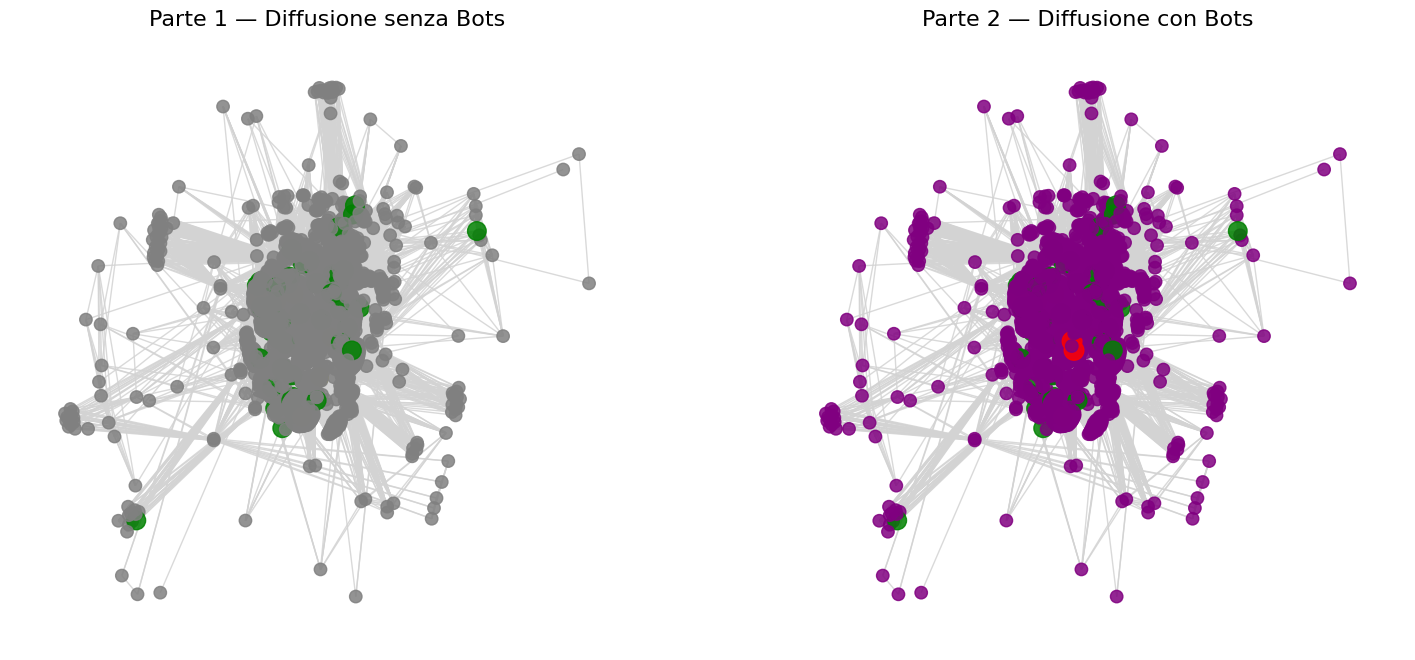

In [164]:
roles = assign_roles(G, n_verifiers=50, n_unintentional=10)
roles_bots = assign_bots(G, roles, n_bots=3, mode="betweenness")

messages = simulate_spread(G, roles, threshold=0.3)
messages_bots = simulate_spread_with_bots(G, roles_bots, threshold=0.3)

print("Senza Bots:", analyze(messages))
print("Con Bots:", analyze(messages_bots))

plot_comparison(G, roles, roles_bots, messages, messages_bots)